In [ ]:
#codigo basado de la actividad 5.cnn usando train, test, accuracy, loss function, optimizer y el primer modelo

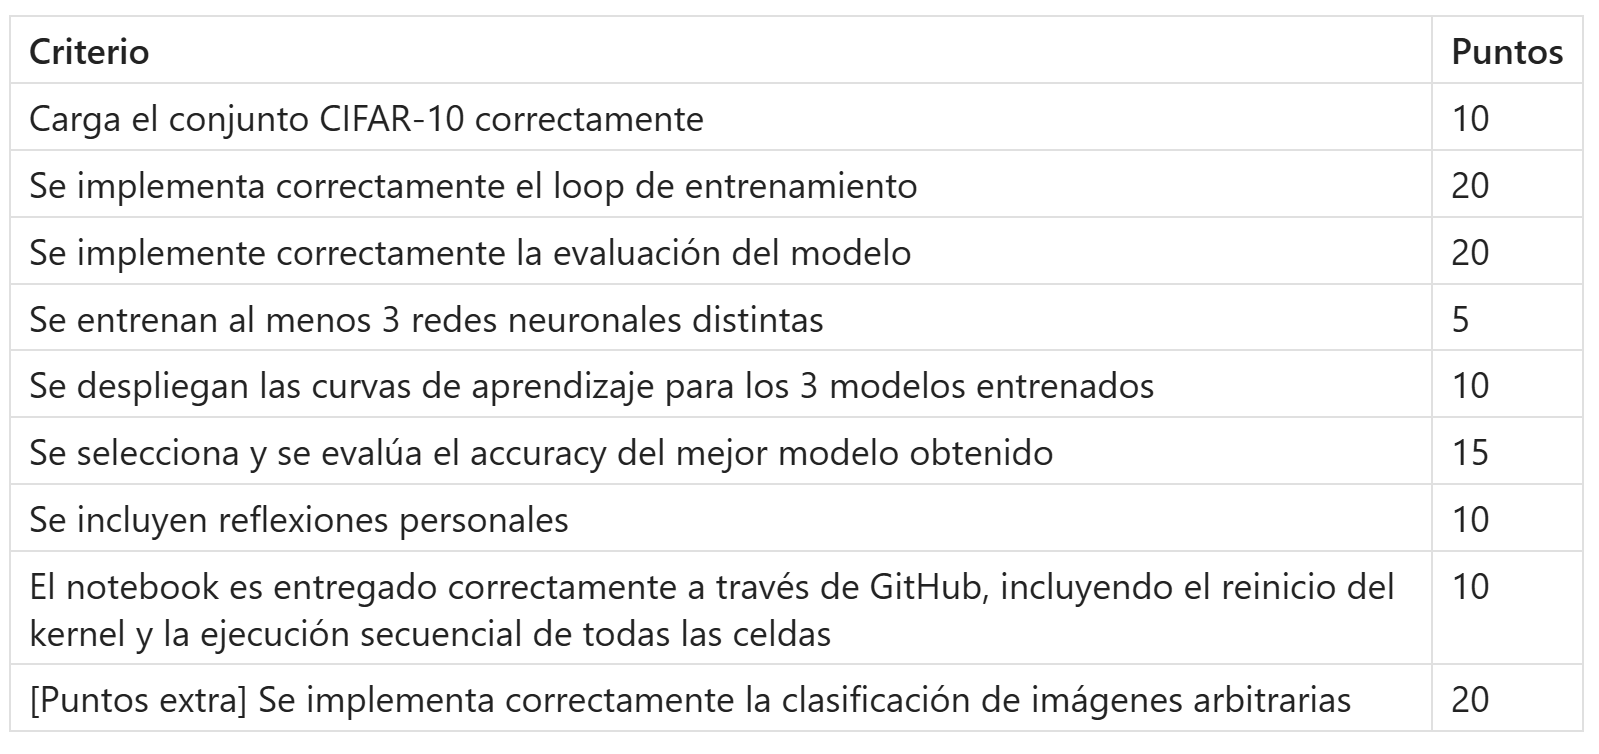

In [ ]:
# Carga los datos de CIFAR-10 utilizando el dataset incluido en PyTorch (torchvision)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CIFAR10 #Cifar dataset
from torch.optim import Adam #optimizer
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

Preparar dataset (basado en 5.cnn pero enves de csv ahora es de PIL)

In [ ]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3

class CifarDataset(Dataset):#
    def __init__(self, base_df):
        #x_df = base_df.copy() Original en ASLDataset
        #y_df = x_df.pop('label')
        x_df = []
        y_df = []

        for img, label in base_df: #cada imagen y cada etiqueta se itera


          #Por defecto, el dataset cargará las imágenes como instancias de PIL.Image, investiga cómo convertirlo a tensores.

          img = transforms.ToTensor()(img) #se convierte a tensor  https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html
          x_df.append(img)
          y_df.append(label)

        #x_df = x_df.values / 255
        #x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        #esto era el proceso pasado para convertir cuando era con csv


        self.xs = torch.stack(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [ ]:
#El dataset ya está particionado en train y test. Para esta actividad, no es necesario particionar en validation

train_dataset = CIFAR10(root="./data", train=True, download=True) # https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html
test_dataset = CIFAR10(root="./data", train=False, download=True)

train_data = CifarDataset(train_dataset)
test_data = CifarDataset(test_dataset)

100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s]


In [ ]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

calcular accuracy, de la actividad pasada

In [ ]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [ ]:
#Implementa el loop de entrenamiento


def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc' : []
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

# Cada época corresponde a una iteración completa sobre el dataset de train
    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            # Dentro de cada época, el dataset se procesará en mini batches
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            # Los pesos de la red neuronal se actualizarán una vez por cada mini batch
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, X_batch.size(0)) * X_batch.size(0)#Correcion por gemini de error

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = train_acc / len(_train_loader.dataset)

        ## Al finalizar cada época, calcula la pérdida correspondiente al conjunto de test
        epoch_test_loss, epoch_test_acc = test(_model, _test_loader, _criterion)#test

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",#test
            test_acc=f"{epoch_test_acc:.4f}",#test
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['test_loss'].append(epoch_test_loss)#tets
        res['test_acc'].append(epoch_test_acc)#test

    return res

In [ ]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, x.size(0))* x.size(0) #correccion de gemini de error

    epoch_test_loss = test_loss / len(_test_loader.dataset)
    epoch_test_acc = test_acc / len(_test_loader.dataset)

    return epoch_test_loss, epoch_test_acc

In [ ]:
#Define una red neuronal convolucional para clasificación multi clase.

#igual al ejemplo peroo ahora son 3 por los RGB
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512), #4x4 porque son de 32x32 no de 28x28 como en el ejemplo
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)#se planea cambiar a tres clases de dog, frog y horse
)

model_cnn = model_cnn.to(device)

In [ ]:
#Define un optimizador para tu red neuronal (se recomienda SGD o Adam) y Define una función de pérdida apropiada para el dataset

epochs = 20
loss_function = nn.CrossEntropyLoss()#funcion de predida
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:52<00:00,  5.62s/epoch, test_acc=0.7413, test_loss=0.8558, train_acc=0.8652, train_loss=0.3727]


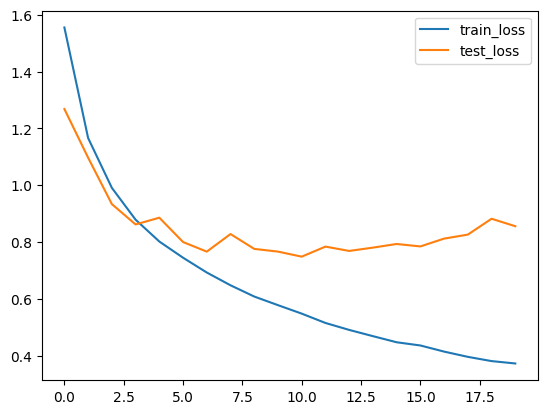

In [ ]:
plt.plot(cnn_res['train_loss'], label='train_loss')
plt.plot(cnn_res['test_loss'], label='test_loss')
plt.legend()
plt.show()

In [ ]:
#Entrena por lo menos 3 redes neuronales distintas alguno(s) de los siguientes parámetros. Lo único que deberá cambiar es la arquitectura de las redes neuronales; el resto de hiperparámetros de entrenamiento deberán ser iguales (número de épocas, optimizador, etc.)


### modelo 2



In [ ]:
model_cnn_2 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 10)
).to(device)




#Define un optimizador para tu red neuronal (se recomienda SGD o Adam) y Define una función de pérdida apropiada para el dataset

epochs = 20
loss_function = nn.CrossEntropyLoss()#funcion de predida
optimizer = Adam(model_cnn_2.parameters())

cnn_res2 = train(model_cnn_2, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [02:48<00:00,  8.42s/epoch, test_acc=0.7410, test_loss=0.8974, train_acc=0.8533, train_loss=0.4037]


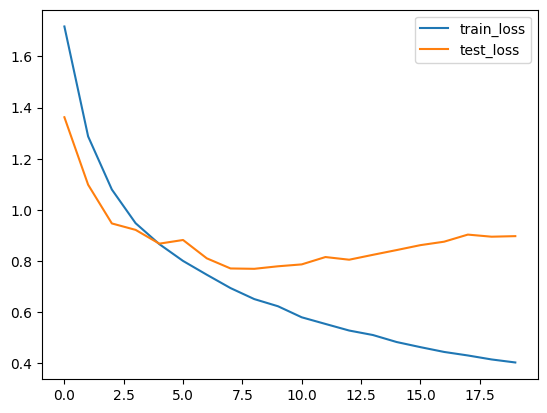

In [ ]:
plt.plot(cnn_res2['train_loss'], label='train_loss')
plt.plot(cnn_res2['test_loss'], label='test_loss')
plt.legend()
plt.show()

### modelo 3

In [ ]:
model_cnn_3 = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

#Define un optimizador para tu red neuronal (se recomienda SGD o Adam) y Define una función de pérdida apropiada para el dataset

epochs = 20
loss_function = nn.CrossEntropyLoss()#funcion de predida
optimizer = Adam(model_cnn_3.parameters())

cnn_res3 = train(model_cnn_3, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:52<00:00,  5.64s/epoch, test_acc=0.6787, test_loss=1.1537, train_acc=0.8488, train_loss=0.4234]


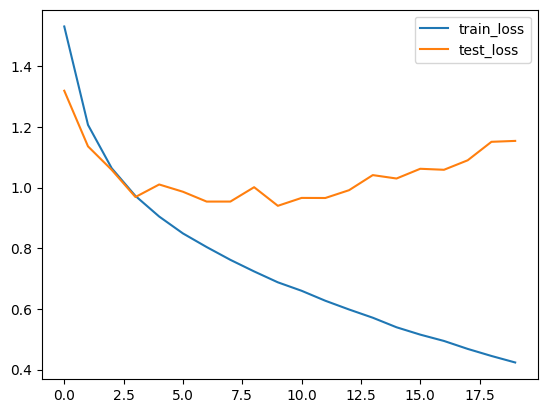

In [ ]:
plt.plot(cnn_res3['train_loss'], label='train_loss')
plt.plot(cnn_res3['test_loss'], label='test_loss')
plt.legend()
plt.show()

In [ ]:
#Al finalizar el entrenamiento, evalúa el mejor de los modelos obtenidos en términos del conjunto de test (accuracy)

test_loss1, test_acc1 = test(model_cnn, test_loader, loss_function)
test_loss2, test_acc2 = test(model_cnn_2, test_loader, loss_function)
test_loss3, test_acc3 = test(model_cnn_3, test_loader, loss_function)

print(test_acc1, test_acc2, test_acc3)

0.7413 0.741 0.6787


In [ ]:
#Agrega tus reflexiones personales sobre esta actividad

In [ ]:
Los modelos entrenados muestran su deficiencia en las graficas como en las pruebas.

Ninguno llega al 80% lo cual los hace modelos no confiables. Las combinaciones usadas de parametros no fueron las indicadas o tal vez se requiera usar mas datos o data augmentation.

Estan sobreajustandose y como resultado no es un modelo de confianza.

Tambien como esperado, el modelo que estaba de ejemplo en clase que tuvo la calificación más alta de .7413.

In [ ]:
# #Para puntos extra:



# [20 puntos] Implementa la funcionalidad de clasificar imágenes arbitrarias proporcionadas por el usuario.
# Crea una función que reciba la ruta en disco a la imagen a clasificar y regresa la etiqueta (en forma textual)
# La imagen proporcionada por el usuario deberá procesarse de forma que sea consistente con la entrada esperada por la red neuronal (3 canales de 32x32 px)
# El modelo a utilizar deberá ser el mejor de los modelos obtenidos


In [ ]:
from PIL import Image
import torch
from torchvision import transforms

etiquetas = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def prediccion(path, model):
    model.eval()#poner a evaluacion modo

    transform = transforms.Compose([ #asegurar que sean mismo tamaño que las del dataset
        transforms.Resize((32, 32)), #https://pytorch.org/vision/main/generated/torchvision.transforms.Resize.html
        transforms.ToTensor()
    ])

    image = Image.open(path).convert("RGB")#sea tambien en RGB https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.convert
    image = transform(image)#hace la transformacion
    image = image.unsqueeze(0).to(device) #https://pytorch.org/docs/stable/generated/torch.unsqueeze.html

    with torch.no_grad(): #https://pytorch.org/docs/stable/generated/torch.no_grad.html
        outputs = model(image)
        pred = torch.argmax(outputs, dim=1).item() #https://pytorch.org/docs/stable/generated/torch.argmax.html

    return etiquetas[pred]

In [29]:
best_model = model_cnn
prediccion("img.jpg", best_model)

'horse'

Correcto

In [30]:
best_model = model_cnn_2
prediccion("dog.jpg", best_model)

'deer'

incorrecto

In [31]:
best_model = model_cnn_2
prediccion("dog2.jpg", best_model)

'frog'

Incorrecto

In [32]:
best_model = model_cnn_2
prediccion("frog.jpg", best_model)

'frog'

Correcto